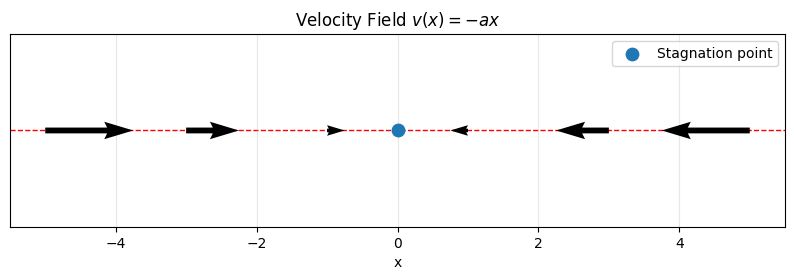

In [1]:
# ENAE414 problem 1
import numpy as np
import matplotlib.pyplot as plt

# Choose a positive value of a for visualization
a = 1

# Positions along the x-axis
x = np.linspace(-5, 5, 21)

# Velocity field: v(x) = -ax
v = -a * x

# y = 0 because this is a 1D flow
y = np.zeros_like(x)

plt.figure(figsize=(10, 2.5))

skip = 4

plt.quiver(
    x[::skip],
    y[::skip],
    v[::skip],
    np.zeros_like(v[::skip]),
    angles="xy",
    scale_units="xy",
    scale=4,
    zorder=2
)
plt.axhline(0, linewidth=1, ls="--", color = "red", zorder=1)
# Mark the stagnation point
plt.scatter(0, 0, s=80, zorder=3, label="Stagnation point")

# Draw coordinate axis


plt.xlim(-5.5, 5.5)
plt.ylim(-1, 1)

plt.xlabel("x")
plt.title(r"Velocity Field $v(x)=-ax$")

plt.yticks([])
plt.grid(alpha=0.3)
plt.legend()

plt.show()

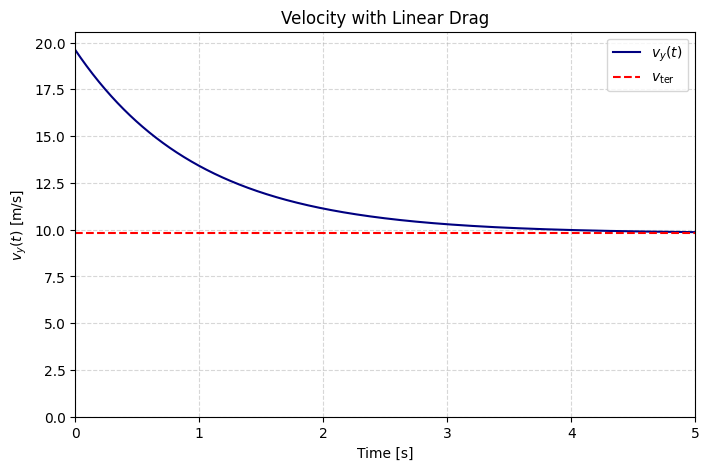

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# PHYS410 HW2 - Problem 1
# Constants
m = 1.0      # kg
g = 9.8      # m/s^2
b = 1.0      # kg/s
# Terminal and initial velocities
vter = m * g / b
vy0 = 2 * vter
def velocity(time):
    """
    Velocity for linear drag:
    v_y(t) = (v_y0 - v_ter)e^(-bt/m) + v_ter
    """
    v_y = (vy0 - vter) * np.exp(-(b / m) * time) + vter
    return v_y
# Time array
ti = 0
tf = 5*m / b
steps = 1000
time = np.linspace(ti, tf, steps)
vy_t = velocity(time)
# Plot
plt.figure(figsize=(8, 5))
plt.plot(time,vy_t,label=r"$v_y(t)$", color = "navy")
plt.axhline(y=vter,linestyle="--",label=r"$v_{\mathrm{ter}}$", color = "red") # Terminal velocity line
plt.xlabel("Time [s]")
plt.ylabel(r"$v_y(t)$ [m/s]")
plt.xlim(ti, tf)
plt.ylim(0, 2.1 * vter)
plt.title("Velocity with Linear Drag")
plt.grid(ls="--", alpha=0.5)
plt.legend()
plt.show()

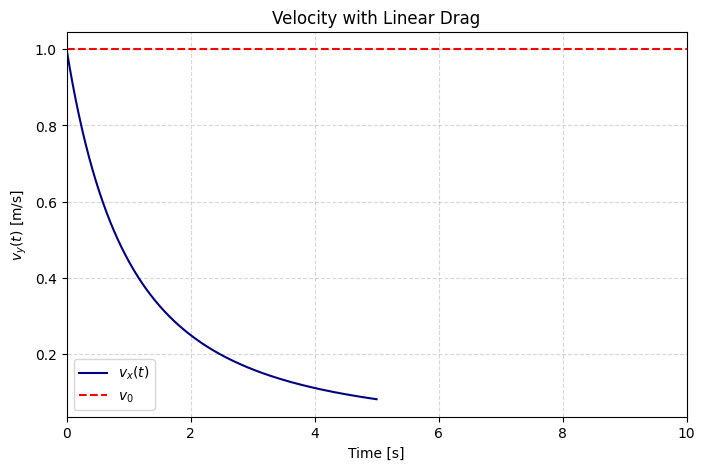

In [3]:
def vel_x(time):
    m = 1
    v0 = 1
    c = 1
    v_x = (v0/(0.5*np.sqrt(v0)*(c/m)*time+1)**2)
    return v_x
m = 1
v0 = 1
c = 1
ti = 0
tf = 10
steps = 1000
vx_t = vel_x(time)
# Plot
plt.figure(figsize=(8, 5))
plt.plot(time,vx_t,label=r"$v_x(t)$", color = "navy")
plt.axhline(y=v0,linestyle="--",label=r"$v_{\mathrm{0}}$", color = "red") # Terminal velocity line
plt.xlabel("Time [s]")
plt.ylabel(r"$v_y(t)$ [m/s]")
plt.xlim(ti, tf)
plt.title("Velocity with Linear Drag")
plt.grid(ls="--", alpha=0.5)
plt.legend()
plt.show()

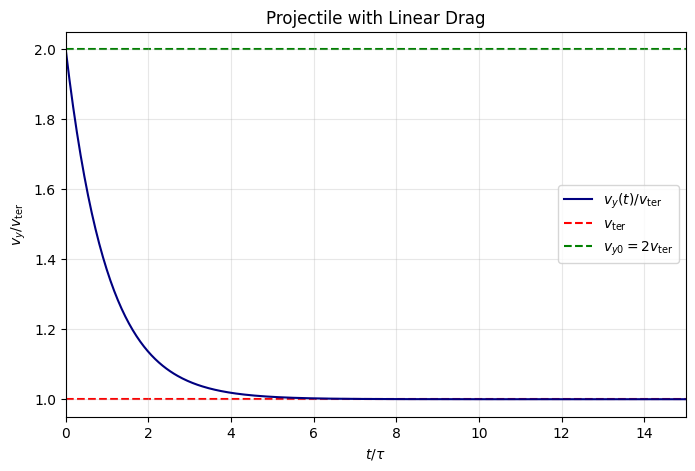

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Dimensionless time t/tau
t_tau = np.linspace(0, 15, 500)

# vy / v_terminal
vy_vter = 1 + np.exp(-t_tau)

plt.figure(figsize=(8, 5))

plt.plot(t_tau, vy_vter, label=r"$v_y(t)/v_{\rm ter}$", color = "navy", zorder = 2)
plt.axhline(
    1,
    linestyle="--",
    label=r"$v_{\rm ter}$",
    color = "red",
    zorder = 1
)
plt.axhline(
    2,
    linestyle="--",
    label=r"$v_{y0} = 2v_{\rm ter}$",
    color = "green",
    zorder = 1
)
plt.xlim(t_tau.min(), t_tau.max())
plt.xlabel(r"$t/\tau$")
plt.ylabel(r"$v_y/v_{\rm ter}$")
plt.title("Projectile with Linear Drag")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

v0 [m/s]    Drag [s]    Vacuum [s]
     1.0       0.102         0.102
    10.0       0.994         1.020
    20.0       1.854         2.041
    30.0       2.531         3.061
    40.0       3.043         4.082


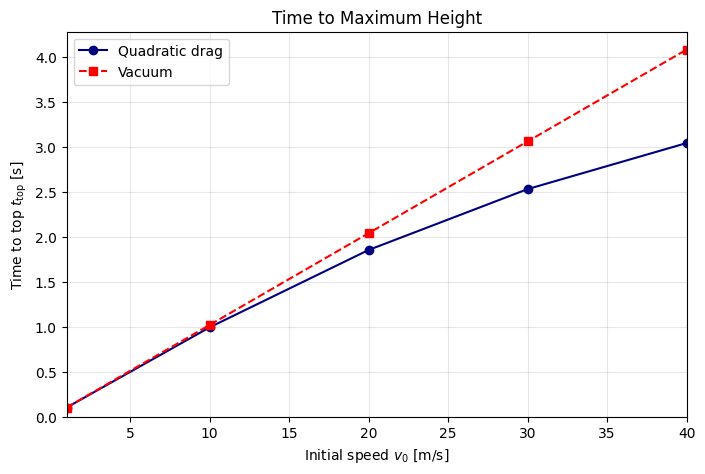

In [18]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8
vter = 35.0

v0 = np.array([1, 10, 20, 30, 40], dtype=float)

# Quadratic drag
t_drag = (vter / g) * np.arctan(v0 / vter)

# Vacuum
t_vacuum = v0 / g

# Print table
print("v0 [m/s]    Drag [s]    Vacuum [s]")
for vi, td, tv in zip(v0, t_drag, t_vacuum):
    print(f"{vi:8.1f}    {td:8.3f}    {tv:10.3f}")

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    v0,
    t_drag,
    "o-",
    label="Quadratic drag"
    , color ="navy"
)

plt.plot(
    v0,
    t_vacuum,
    "s--",
    label="Vacuum"
    , color = "red"
)
plt.xlim(v0[0], v0[-1])
plt.ylim(0,)
plt.xlabel(r"Initial speed $v_0$ [m/s]")
plt.ylabel(r"Time to top $t_{\rm top}$ [s]")
plt.title("Time to Maximum Height")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

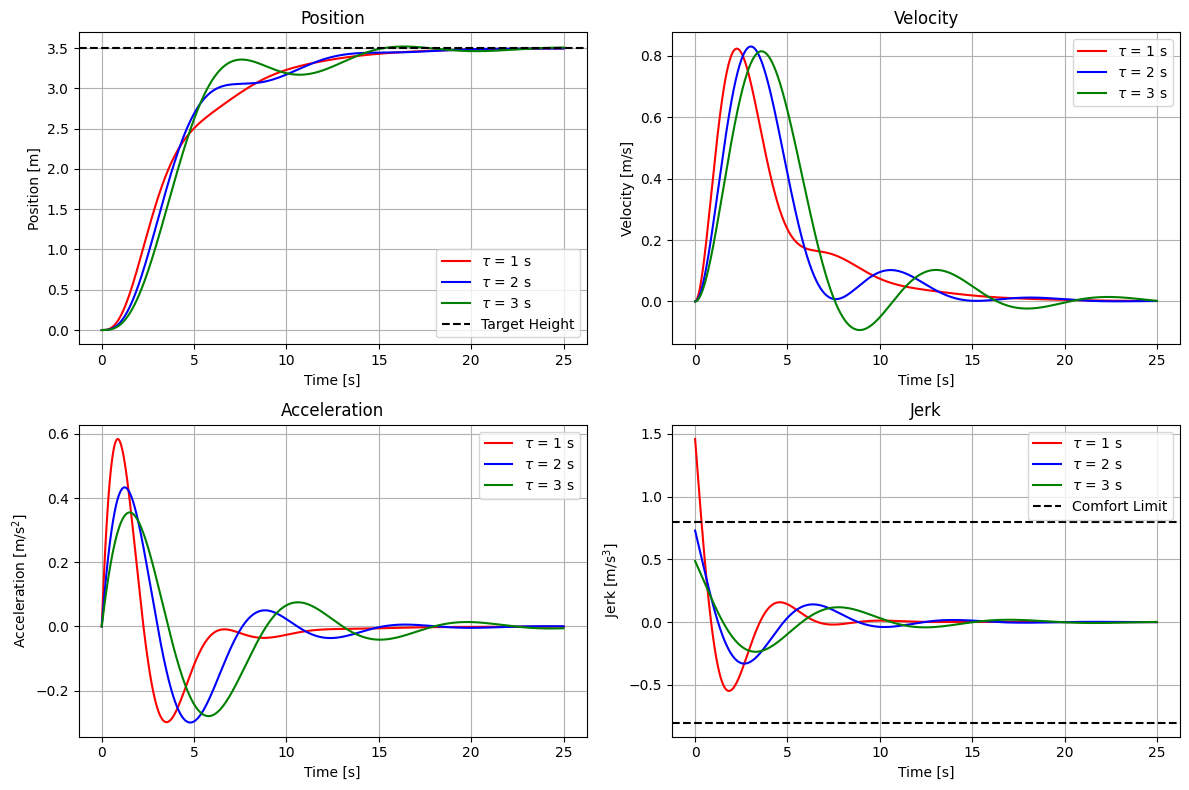

tau = 1 s | max jerk = 1.458 m/s^3
tau = 2 s | max jerk = 0.729 m/s^3
tau = 3 s | max jerk = 0.486 m/s^3


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# given values
m = 1200
c = 400
Kp = 500
Kd = 1800
H = 3.5

taus = [1, 2, 3]
colors = ["red", "blue", "green"]

# time
t = np.linspace(0, 25, 5000)

# initial conditions [position, velocity, acceleration]
initial = [0, 0, 0]


# elevator differential equation
def elevator(z, t, tau):

    x = z[0]
    v = z[1]
    a = z[2]

    jerk = (
        Kp*H
        - Kp*x
        - (c + Kd)*v
        - (m + tau*c)*a
    ) / (tau*m)

    return [v, a, jerk]


# solve for each value of tau
results = {}

for tau in taus:

    sol = odeint(elevator, initial, t, args=(tau,))

    x = sol[:, 0]
    v = sol[:, 1]
    a = sol[:, 2]

    # use the differential equation to get jerk
    j = (
        Kp*H
        - Kp*x
        - (c + Kd)*v
        - (m + tau*c)*a
    ) / (tau*m)

    results[tau] = [x, v, a, j]


# make plots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for tau, color in zip(taus, colors):

    ax[0, 0].plot(
        t, results[tau][0],
        color=color,
        label=rf"$\tau$ = {tau} s"
    )

    ax[0, 1].plot(
        t, results[tau][1],
        color=color,
        label=rf"$\tau$ = {tau} s"
    )

    ax[1, 0].plot(
        t, results[tau][2],
        color=color,
        label=rf"$\tau$ = {tau} s"
    )

    ax[1, 1].plot(
        t, results[tau][3],
        color=color,
        label=rf"$\tau$ = {tau} s"
    )


# target height
ax[0, 0].axhline(
    H,
    color="black",
    linestyle="--",
    label="Target Height"
)

# jerk limits
ax[1, 1].axhline(
    0.8,
    color="black",
    linestyle="--",
    label="Comfort Limit"
)

ax[1, 1].axhline(
    -0.8,
    color="black",
    linestyle="--"
)


# labels
ax[0, 0].set_title("Position")
ax[0, 0].set_xlabel("Time [s]")
ax[0, 0].set_ylabel("Position [m]")

ax[0, 1].set_title("Velocity")
ax[0, 1].set_xlabel("Time [s]")
ax[0, 1].set_ylabel("Velocity [m/s]")

ax[1, 0].set_title("Acceleration")
ax[1, 0].set_xlabel("Time [s]")
ax[1, 0].set_ylabel(r"Acceleration [m/s$^2$]")

ax[1, 1].set_title("Jerk")
ax[1, 1].set_xlabel("Time [s]")
ax[1, 1].set_ylabel(r"Jerk [m/s$^3$]")


# grid and legends
for row in ax:
    for plot in row:
        plot.grid()
        plot.legend()

plt.tight_layout()
plt.show()


# maximum jerk for each elevator
for tau in taus:

    max_jerk = np.max(np.abs(results[tau][3]))

    print(
        "tau =", tau,
        "s | max jerk =",
        round(max_jerk, 3),
        "m/s^3"
    )

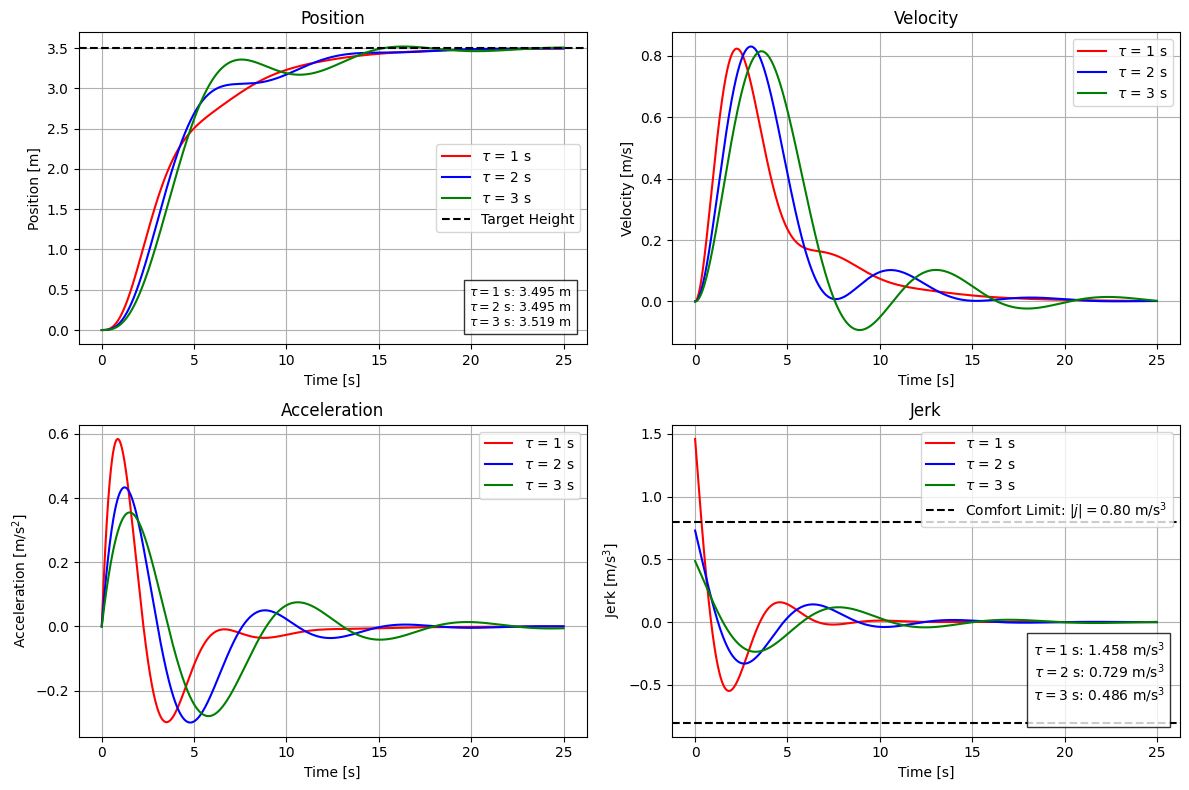

tau = 1 s | max jerk = 1.458 m/s^3
tau = 2 s | max jerk = 0.729 m/s^3
tau = 3 s | max jerk = 0.486 m/s^3


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# given values
m = 1200
c = 400
Kp = 500
Kd = 1800
H = 3.5
taus = [1, 2, 3]
colors = ["red", "blue", "green"]

# time
t = np.linspace(0, 25, 5000)

# initial conditions [position, velocity, acceleration]
initial = [0, 0, 0]

# elevator differential equation
def elevator(z, t, tau):
    x = z[0]
    v = z[1]
    a = z[2]
    jerk = (Kp*H - Kp*x - (c + Kd)*v - (m + tau*c)*a) / (tau*m)
    return [v, a, jerk]

# solve for each value of tau
results = {}
for tau in taus:
    sol = odeint(elevator, initial, t, args=(tau,))
    x = sol[:, 0]
    v = sol[:, 1]
    a = sol[:, 2]
    # use the differential equation to get jerk
    j = (Kp*H - Kp*x - (c + Kd)*v - (m + tau*c)*a) / (tau*m)
    results[tau] = [x, v, a, j]

# make plots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for tau, color in zip(taus, colors):

    ax[0, 0].plot(t, results[tau][0],color=color,label=rf"$\tau$ = {tau} s")
    ax[0, 1].plot(t, results[tau][1],color=color,label=rf"$\tau$ = {tau} s")
    ax[1, 0].plot( t, results[tau][2], color=color,label=rf"$\tau$ = {tau} s")
    ax[1, 1].plot( t, results[tau][3], color=color, label=rf"$\tau$ = {tau} s")

# target height
ax[0, 0].axhline( H,color="black",linestyle="--",label="Target Height")
# maximum height values
height_text = ""
for tau in taus:
    max_height = np.max(results[tau][0])
    height_text += ( rf"$\tau={tau}$ s: "rf"{max_height:.3f} m""\n")
# put maximum height values on position plot
ax[0, 0].text(0.97,0.05,height_text.strip(),transform=ax[0, 0].transAxes,horizontalalignment="right",
              verticalalignment="bottom",fontsize=9,
              bbox=dict(facecolor="white",alpha=0.8))
# jerk limits
ax[1, 1].axhline( 0.8,color="black",linestyle="--",label=r"Comfort Limit: $|j|=0.80$ m/s$^3$")

ax[1, 1].axhline( -0.8, color="black", linestyle="--")

# maximum jerk values
jerk_text = ""
for tau in taus:
    max_jerk = np.max(np.abs(results[tau][3]))
    jerk_text += (
        rf"$\tau={tau}$ s: "
        rf"{max_jerk:.3f} m/s$^3$"
        "\n")

# put maximum jerk values on jerk plot
ax[1, 1].text(0.97,0.05,jerk_text,transform=ax[1, 1].transAxes,horizontalalignment="right",verticalalignment="bottom",bbox=dict(facecolor="white",alpha=0.8))

# labels
ax[0, 0].set_title("Position")
ax[0, 0].set_xlabel("Time [s]")
ax[0, 0].set_ylabel("Position [m]")

ax[0, 1].set_title("Velocity")
ax[0, 1].set_xlabel("Time [s]")
ax[0, 1].set_ylabel("Velocity [m/s]")

ax[1, 0].set_title("Acceleration")
ax[1, 0].set_xlabel("Time [s]")
ax[1, 0].set_ylabel(r"Acceleration [m/s$^2$]")

ax[1, 1].set_title("Jerk")
ax[1, 1].set_xlabel("Time [s]")
ax[1, 1].set_ylabel(r"Jerk [m/s$^3$]")

# grid and legends
for row in ax:
    for plot in row:
        plot.grid()
        plot.legend()

plt.tight_layout()
# save figure
plt.savefig( "PHYS410_HW2_Problem5_partA.png",dpi=300, bbox_inches="tight")
plt.show()
# maximum jerk for each elevator
for tau in taus:
    max_jerk = np.max(np.abs(results[tau][3]))
    print( "tau =", tau,"s | max jerk =",round(max_jerk, 3),"m/s^3")